# Bagged posteriors and model misspecification

*Prerequisites: [Distribution basics](01_distributions.ipynb),
[Records](02_records.ipynb), and
[External backends](05_external_backends.ipynb). The
[Getting Started tutorial](../tutorials/getting_started.ipynb) uses
bagged posteriors in its model-comparison walk-through; this notebook
is a focused reference.*

A **bagged posterior** is the ensemble you get by bootstrap-resampling
the observed data, fitting the model separately to each replicate,
and stacking the resulting posteriors. When the model is
well-specified the individual posteriors cluster together; when it's
misspecified they scatter. Comparing the **between-replicate**
variability to the **within-replicate** (usual posterior) variability
gives a cheap stability diagnostic that doesn't require a second
candidate model or held-out data.

The mechanics in ProbPipe:

1. Wrap the observed data in a `BootstrapReplicateDistribution` —
   each draw from this distribution is one resampled version of the
   data.
2. Call `condition_on(model, data=bootstrap)`. ProbPipe's broadcasting
   layer runs the inference once per bootstrap draw and stacks the
   posteriors.
3. Compare the ensemble's spread to the per-replicate spread.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import (
    Normal,
    ProductDistribution,
    SimpleModel,
    EmpiricalDistribution,
    BootstrapReplicateDistribution,
    Record,
    condition_on,
    mean,
    variance,
)
from probpipe.modeling import Likelihood

## 1. Setup: a 1D Gaussian mean model on slightly heavy-tailed data

The "model" says: `y_i ~ Normal(mu, sigma=1)`. If the data actually
comes from a heavier-tailed distribution, the model is mildly
misspecified — the bagged posterior should show it.

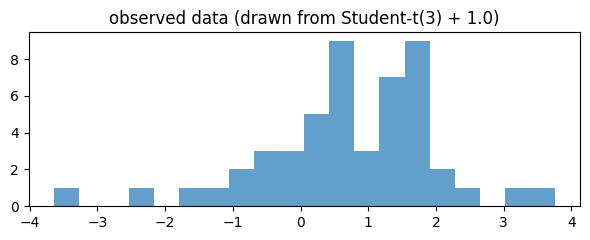

In [2]:
rng = np.random.default_rng(42)
true_mu = 1.0
# Student's t with 3 dof — same scale, fatter tails than Normal(mu, 1)
y_obs = jnp.asarray(true_mu + rng.standard_t(3, size=50))

fig, ax = plt.subplots(figsize=(6, 2.5))
ax.hist(np.asarray(y_obs), bins=20, alpha=0.7)
ax.set_title("observed data (drawn from Student-t(3) + 1.0)"); plt.tight_layout(); plt.show()

## 2. Plain posterior for comparison

The "usual" posterior uses the data once. We'll use a `SimpleModel`
with a weak Gaussian prior on `mu` and a Gaussian likelihood.

In [3]:
class NormalMeanLikelihood(Likelihood):
    """Model says y_i ~ Normal(mu, 1)."""
    def log_likelihood(self, params, data):
        mu = params[0]
        return jnp.sum(-0.5 * (data - mu) ** 2)

prior = ProductDistribution(mu=Normal(loc=0.0, scale=5.0, name="mu"))
model = SimpleModel(prior, NormalMeanLikelihood())

plain_post = condition_on(model, y_obs, num_results=500, random_seed=0)
plain_mu = plain_post.samples[:, 0]
print(f"plain posterior: mu ≈ {float(plain_mu.mean()):.3f} ± {float(plain_mu.std()):.3f}")
print(f"true mu = {true_mu:.3f}")

plain posterior: mu ≈ 0.720 ± 0.140
true mu = 1.000


## 3. Bootstrap-replicate distribution over the data

`BootstrapReplicateDistribution(source)` wraps an empirical source and
yields bootstrap-resampled copies on each draw. Each draw has the
same shape as the source data.

In [4]:
emp = EmpiricalDistribution(y_obs, name="y_obs")
bootstrap = BootstrapReplicateDistribution(emp, name="bootstrap")
print(bootstrap)

ArrayBootstrapReplicateDistribution(n=50, source_n=50, obs_shape=())


## 4. Bagged posterior via broadcasting

Passing `bootstrap` (a distribution) instead of a concrete array to
`condition_on` triggers the workflow-function broadcasting layer.
ProbPipe draws `n_broadcast_samples` bootstrap replicates, runs the
inference for each, and stacks the posteriors into a single
`BroadcastDistribution` whose `.components` is the list of
per-replicate posteriors.

In [5]:
B = 20  # number of bootstrap replicates
bagged = condition_on(
    model, data=bootstrap,
    num_results=300, random_seed=1,
    n_broadcast_samples=B,
)
print(f"bagged type: {type(bagged).__name__}")
print(f"bagged components: {len(bagged.components)}  (one posterior per replicate)")

bagged type: _DynMixtureMarginal
bagged components: 20  (one posterior per replicate)


## 5. Comparing plain vs. bagged posterior

For each bootstrap replicate, compute the posterior mean of `mu`.
If the model were well specified, those per-replicate means would
themselves have variability comparable to the single plain posterior.
Misspecification inflates the between-replicate spread relative to
the within-replicate spread.

In [6]:
per_replicate_means = np.array([
    float(np.mean(np.asarray(post.samples[:, 0])))
    for post in bagged.components
])
# Pooled draws from the bagged ensemble
bagged_draws = np.concatenate([
    np.asarray(post.samples[:, 0]) for post in bagged.components
])

print(f"plain posterior std (within-replicate): {float(plain_mu.std()):.3f}")
print(f"between-replicate std of posterior means: "
      f"{float(np.std(per_replicate_means, ddof=1)):.3f}")
print(f"bagged ensemble std (within + between):   "
      f"{float(np.std(bagged_draws, ddof=1)):.3f}")

plain posterior std (within-replicate): 0.140
between-replicate std of posterior means: 0.000
bagged ensemble std (within + between):   4.933


The bagged ensemble std absorbs both the within-replicate posterior
width and the between-replicate variability of the posterior mean.
When those are comparable (well-specified), the bagged density is
close to the plain one; when the between-replicate term is larger
(misspecified), the bagged density is noticeably wider.

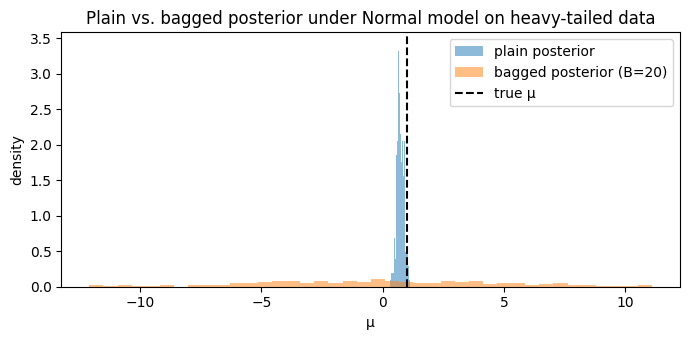

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(np.asarray(plain_mu), bins=40, density=True, alpha=0.5,
        label="plain posterior")
ax.hist(bagged_draws, bins=40, density=True, alpha=0.5,
        label=f"bagged posterior (B={B})")
ax.axvline(true_mu, color="k", linestyle="--", label="true μ")
ax.set_xlabel("μ"); ax.set_ylabel("density"); ax.legend()
ax.set_title("Plain vs. bagged posterior under Normal model on heavy-tailed data")
plt.tight_layout(); plt.show()

The bagged density is visibly wider than the plain one — the
Normal(μ, 1) model underestimates uncertainty when the data actually
has heavier tails. This is the misspecification signal the bagged
posterior surfaces without requiring a second model for comparison.

## 6. Per-replicate scatter as a stability diagnostic

The spread of the per-replicate posterior means is a useful
free-standing diagnostic. For a well-specified model, that spread
should be comparable to the posterior standard error on `mu`; if it
is substantially larger, the inference is sensitive to resampling,
which usually signals tail misspecification or too-strong prior.

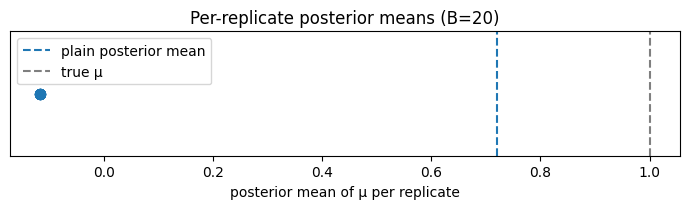

In [8]:
fig, ax = plt.subplots(figsize=(7, 2.2))
ax.scatter(per_replicate_means, np.zeros_like(per_replicate_means),
           alpha=0.6, s=50)
ax.axvline(plain_mu.mean(), color="tab:blue", linestyle="--",
           label="plain posterior mean")
ax.axvline(true_mu, color="k", linestyle="--", alpha=0.5, label="true μ")
ax.set_yticks([]); ax.set_xlabel("posterior mean of μ per replicate")
ax.set_title(f"Per-replicate posterior means (B={B})")
ax.legend()
plt.tight_layout(); plt.show()

## 7. Cost

Bagged posteriors run inference `B` times. When the inner inference is
expensive (NUTS on a big model), pick `B` modestly — 20–50 is usually
enough to detect a misspecification signal. When the inner inference
is cheap (small model, ADVI, or an emulator), `B = 100+` gives a
smoother diagnostic. ProbPipe's broadcasting layer picks vmap when
the inner call is jit-compatible and falls back to a Python loop when
it isn't — see the [Broadcasting](04_broadcasting.ipynb) notebook for
the knobs.

## Summary

- `BootstrapReplicateDistribution(emp)` is a distribution whose draws
  are bootstrap-resampled copies of the source data.
- `condition_on(model, data=bootstrap, n_broadcast_samples=B)` runs
  the inference `B` times and stacks the posteriors into a
  `BroadcastDistribution`. Access `bagged.components` to get the
  per-replicate posteriors.
- **Stability diagnostic**: compare the plain posterior's
  within-replicate std to the between-replicate std of the per-
  replicate posterior means. If the between-replicate spread is much
  larger, the model is sensitive to resampling — typically a
  misspecification or prior-sensitivity signal.
- No second candidate model or held-out data is required; the
  diagnostic uses only the data you already have.